# Find alpha DSE1-4

May 4, 2025 - An attempt to reproduce the find alpha parameter using the DSE genes. The differences in the replicate fits and the shorter delta values make this procedure difficult to reliably reproduce consistently across both replicates. Replicate 1 produces very long alphas > 28, replicate 2 produces very short ones < 8. Whereas we would expect values between 12-20 proportionally to the length of the cell cycle as per Xin Guo's work.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from src.alpha_search import FindAlphaSweepDS

# Load existing results and run correlation analysis
finder2 = FindAlphaSweepDS('output/draft3_run/')

# Or run components individually
finder2.load_existing_results()
finder2.compute_dg1_mg1_ratios()

Creating directory: output/draft3_run//alpha_search...Directory exists. Skipping.
Loading existing results from output/draft3_run//alpha_search/alphas_repl1.csv
Loaded 440 rows of results
Computing DG1/MG1 ratios...
DG1/MG1 ratios computed successfully


dm_ratio
replicate alpha gene          
1         4     DSE1  1.000312
          6     DSE1  1.000001
          8     DSE1  1.119939
          10    DSE1       1.0
          12    DSE1       1.0
...                        ...
2         38    CTS1       1.0
          40    CTS1       1.0
          42    CTS1       1.0
          44    CTS1       1.0
          46    CTS1       1.0

[440 rows x 1 columns]

Applying threshold of 1.6 to ratios...
Replicate 1 feasible range: (30, 44)
Replicate 2 feasible range: (26, 46)
Saved figure to: output/draft3_run//alpha_search/dg1_mg1_ratio_analysis.png
Ratio analysis plot saved to output/draft3_run//alpha_search/dg1_mg1_ratio_analysis.png


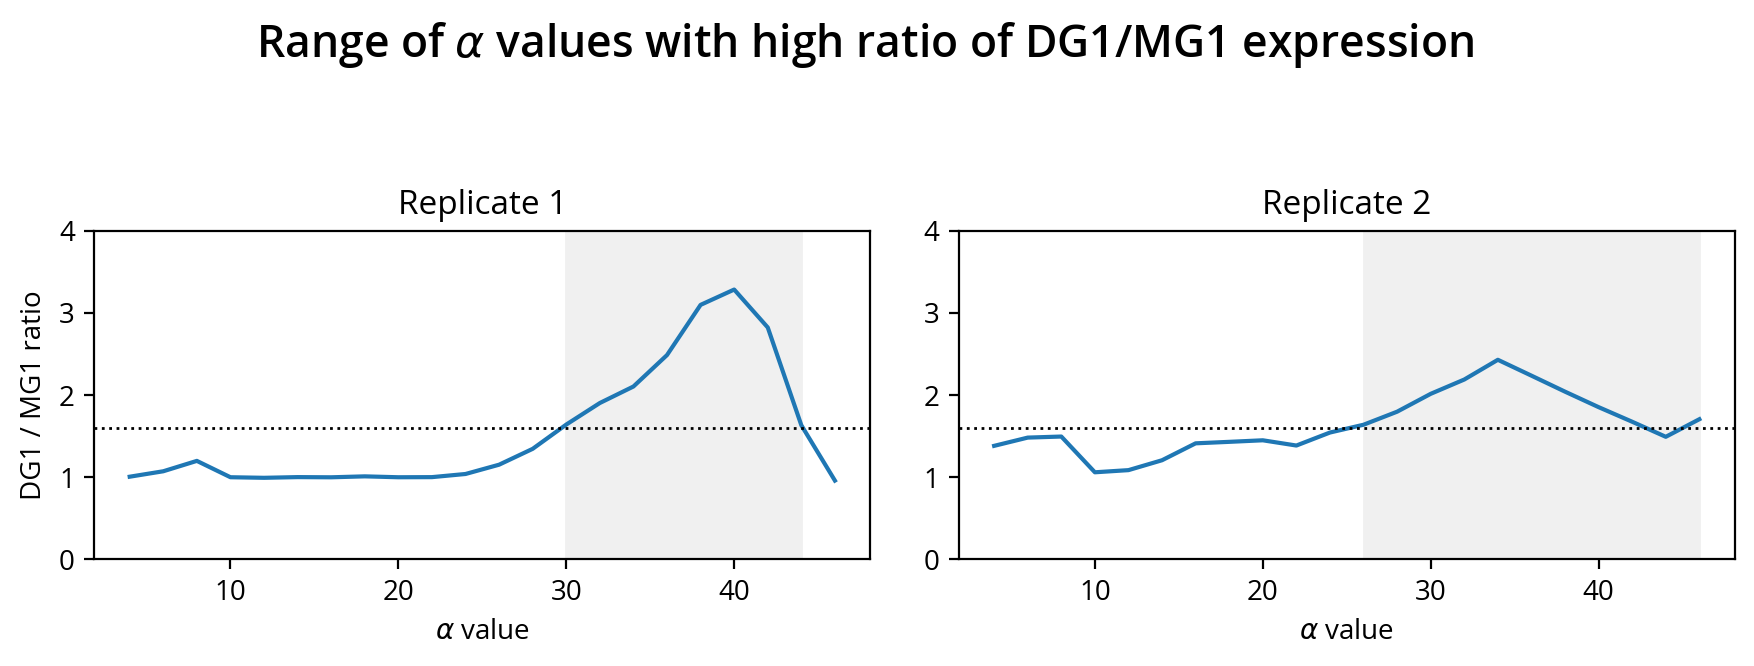

In [4]:
finder2.threshold_ratios(1.6)
finder2.plot_ratio_analysis()

In [5]:
finder2.compute_correlations()

Computing correlations between alpha combinations...
Testing 22x22 = 484 combinations
00:00:09.538
00:00:19.261
00:00:28.868
00:00:38.321
00:00:47.751
00:00:57.210
00:01:06.703
00:01:16.496
00:01:26.239
00:01:35.790
00:01:45.376
00:01:55.046
00:02:04.704
00:02:14.372
00:02:24.622
00:02:34.476
00:02:44.314
00:02:54.146
00:03:03.985
00:03:14.027
00:03:24.828
00:03:34.798
Correlation computation completed


correlation       p_value  n_points
alpha1 alpha2 gene                                      
4      4      DSE1      0.256070  3.644940e-07       384
              DSE2      0.411283  4.164731e-17       384
              DSE3      0.698608  1.687284e-57       384
              DSE4      0.731250  1.896034e-65       384
              ASH1      0.691218  7.577004e-56       384
...                          ...           ...       ...
46     46     EGT2      0.377825  1.779045e-14       384
              AMN1      0.500868  8.874679e-26       384
              PRY3      0.566643  5.392836e-34       384
              SCW11     0.545354  3.901601e-31       384
              CTS1      0.994004  0.000000e+00       384

[4840 rows x 3 columns]

Saved figure to: output/draft3_run//alpha_search/correlation_heatmap.png
Correlation heatmap saved to output/draft3_run//alpha_search/correlation_heatmap.png


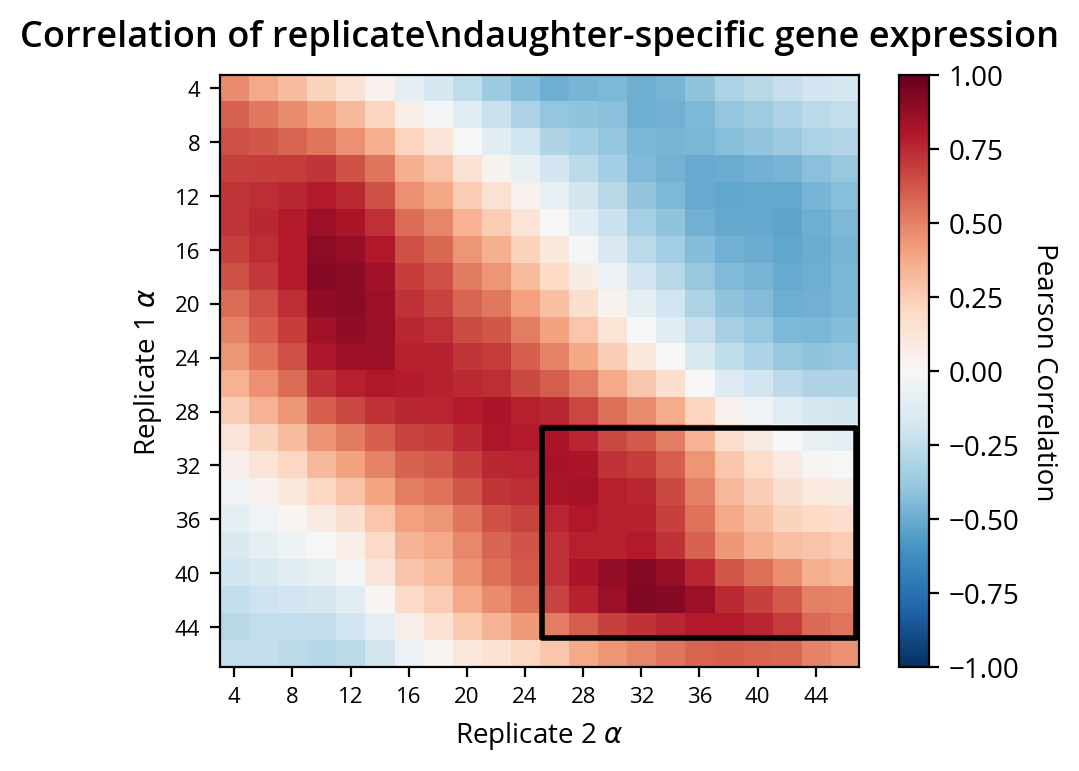

In [6]:
finder2.plot_correlation_heatmap()

In [8]:
all_pairs = finder2.find_optimal_alpha_pairs()
all_pairs.head(10)

Top 20 optimal alpha pairs within feasible ranges:
               correlation
alpha1 alpha2             
42     32         0.922780
40     32         0.918591
42     34         0.909559
40     30         0.875372
       34         0.873510
42     36         0.855471
       30         0.852440
34     28         0.831227
32     26         0.826913
30     26         0.819051
34     26         0.816210
40     28         0.814823
32     28         0.812954
36     28         0.797507
44     38         0.794781
       36         0.791830
38     32         0.791105
       30         0.781157
       28         0.780413
34     30         0.777766


correlation
alpha1 alpha2             
42     32         0.922780
40     32         0.918591
42     34         0.909559
40     30         0.875372
       34         0.873510
42     36         0.855471
       30         0.852440
34     28         0.831227
32     26         0.826913
30     26         0.819051

In [18]:
finder2.run_combined_gene_deconvolution(10)

Top 10 optimal alpha pairs within feasible ranges:
               correlation
alpha1 alpha2             
42     32         0.922780
40     32         0.918591
42     34         0.909559
40     30         0.875372
       34         0.873510
42     36         0.855471
       30         0.852440
34     28         0.831227
32     26         0.826913
30     26         0.819051
Running combined gene deconvolution for 10 alpha pairs...
Deconvolving combined alphas: (42, 32)
DSE1...00:00:11.687
DSE2...00:00:23.176
DSE3...00:00:34.577
DSE4...00:00:45.938
Deconvolving combined alphas: (40, 32)
DSE1...00:00:57.244
DSE2...00:01:08.669
DSE3...00:01:19.898
DSE4...00:01:31.201
Deconvolving combined alphas: (42, 34)
DSE1...00:01:42.827
DSE2...00:01:54.421
DSE3...00:02:06.006
DSE4...00:02:17.687
Deconvolving combined alphas: (40, 30)
DSE1...00:02:28.953
DSE2...00:02:40.348
DSE3...00:02:51.521
DSE4...00:03:02.641
Deconvolving combined alphas: (40, 34)
DSE1...00:03:14.107
DSE2...00:03:25.592
DSE3...00:03

0          1          2          3          4    \
alphas   gene                                                          
(42, 32) DSE1  13.189292  13.146205  13.062619  12.936858  12.773084   
         DSE2  10.096733  10.094022  10.088610  10.080497  10.069702   
         DSE3   4.930343   4.926958   4.920259   4.910302   4.897247   
         DSE4   6.225060   6.214314   6.193004   6.161031   6.118703   
(40, 32) DSE1  11.409498  11.396141  11.369635  11.329940  11.277327   
         DSE2  10.271754  10.267585  10.259311  10.246889  10.230433   
         DSE3   4.592563   4.591751   4.590130   4.587701   4.584473   
         DSE4   5.948516   5.937292   5.915051   5.881691   5.837512   
(42, 34) DSE1  11.208442  11.181308  11.128663  11.049817  10.946855   
         DSE2   9.890306   9.888194   9.883981   9.877663   9.869262   
         DSE3   4.528992   4.528731   4.528214   4.527414   4.526326   
         DSE4   5.653972   5.635897   5.600838   5.548172   5.479528   
(40, 30) DSE1  12.509611  12.490411  12.452411  12.395365  12.319949   
         DSE2  10.742905  10.736529  10.723867  10.704889  10.679732   
         DSE3   4.422728   4.421651   4.419511   4.416295   4.412026   
         DSE4   6.329628   6.318521   6.296390   6.263403   6.219778   
(40, 34) DSE1  10.389743  10.380690  10.362744  10.335815  10.300163   
         DSE2   9.859716   9.857658   9.853547   9.847387   9.839190   
         DSE3   4.736815   4.736169   4.734875   4.732935   4.730347   
         DSE4   5.482997   5.466810   5.435388   5.388285   5.326793   
(42, 36) DSE1  10.048910  10.036760  10.013131   9.977741   9.931450   
         DSE2   9.768736   9.766708   9.762673   9.756633   9.748627   
         DSE3   4.739292   4.738927   4.738196   4.737093   4.735616   
         DSE4   5.366931   5.353244   5.326657   5.286814   5.234761   
(42, 30) DSE1  13.661962  13.616686  13.528815  13.396466  13.224119   
         DSE2  10.798772  10.792396  10.779739  10.760757  10.735594   
         DSE3   4.757302   4.754758   4.749736   4.742192   4.732239   
         DSE4   7.115541   7.101143   7.072582   7.029805   6.973121   
(34, 28) DSE1  10.182469  10.173343  10.155156  10.128055  10.092217   
         DSE2   9.976441   9.972909   9.965885   9.955324   9.941285   
         DSE3   4.542283   4.540869   4.538059   4.533834   4.528223   
         DSE4   5.802568   5.790624   5.766952   5.731449   5.684431   
(32, 26) DSE1  10.089887  10.079387  10.058543  10.027307   9.985928   
         DSE2  10.075433  10.070918  10.061941  10.048483  10.030622   
         DSE3   4.376213   4.374804   4.372001   4.367802   4.362236   
         DSE4   5.578464   5.554571   5.508298   5.438740   5.348062   
(30, 26) DSE1  10.276837  10.254274  10.210426  10.144518  10.058528   
         DSE2   9.497976   9.494791   9.488452   9.478942   9.466308   
         DSE3   4.514095   4.513601   4.512585   4.511088   4.509083   
         DSE4   5.311274   5.292831   5.256997   5.203334   5.133201   

                     5          6          7          8          9    ...  \
alphas   gene                                                         ...   
(42, 32) DSE1  12.592356  12.400142  12.199779  11.995713  11.783247  ...   
         DSE2  10.056288  10.040287  10.021697  10.000560   9.976976  ...   
         DSE3   4.881535   4.863430   4.843048   4.820697   4.796976  ...   
         DSE4   6.067391   6.007479   5.939007   5.862364   5.777892  ...   
(40, 32) DSE1  11.213561  11.139335  11.053733  10.957469  10.852274  ...   
         DSE2  10.210412  10.186946  10.160176  10.130234  10.096967  ...   
         DSE3   4.580458   4.575663   4.570130   4.563871   4.556834  ...   
         DSE4   5.784217   5.722322   5.651078   5.571028   5.483826  ...   
(42, 34) DSE1  10.833971  10.714791  10.591125  10.465910  10.336664  ...   
         DSE2   9.858868   9.846509   9.832202   9.815977   9.797843  ...   
         DSE3   4.524996   4.523394   4.521544   4.519404   4.516779  ..

Combined gene results saved to output/draft3_run//alpha_search/combined_gene_results.csv
Saved figure to: output/draft3_run//alpha_search/combined_gene_deconvolution.png
Combined gene figures saved to output/draft3_run//alpha_search/combined_gene_deconvolution.png


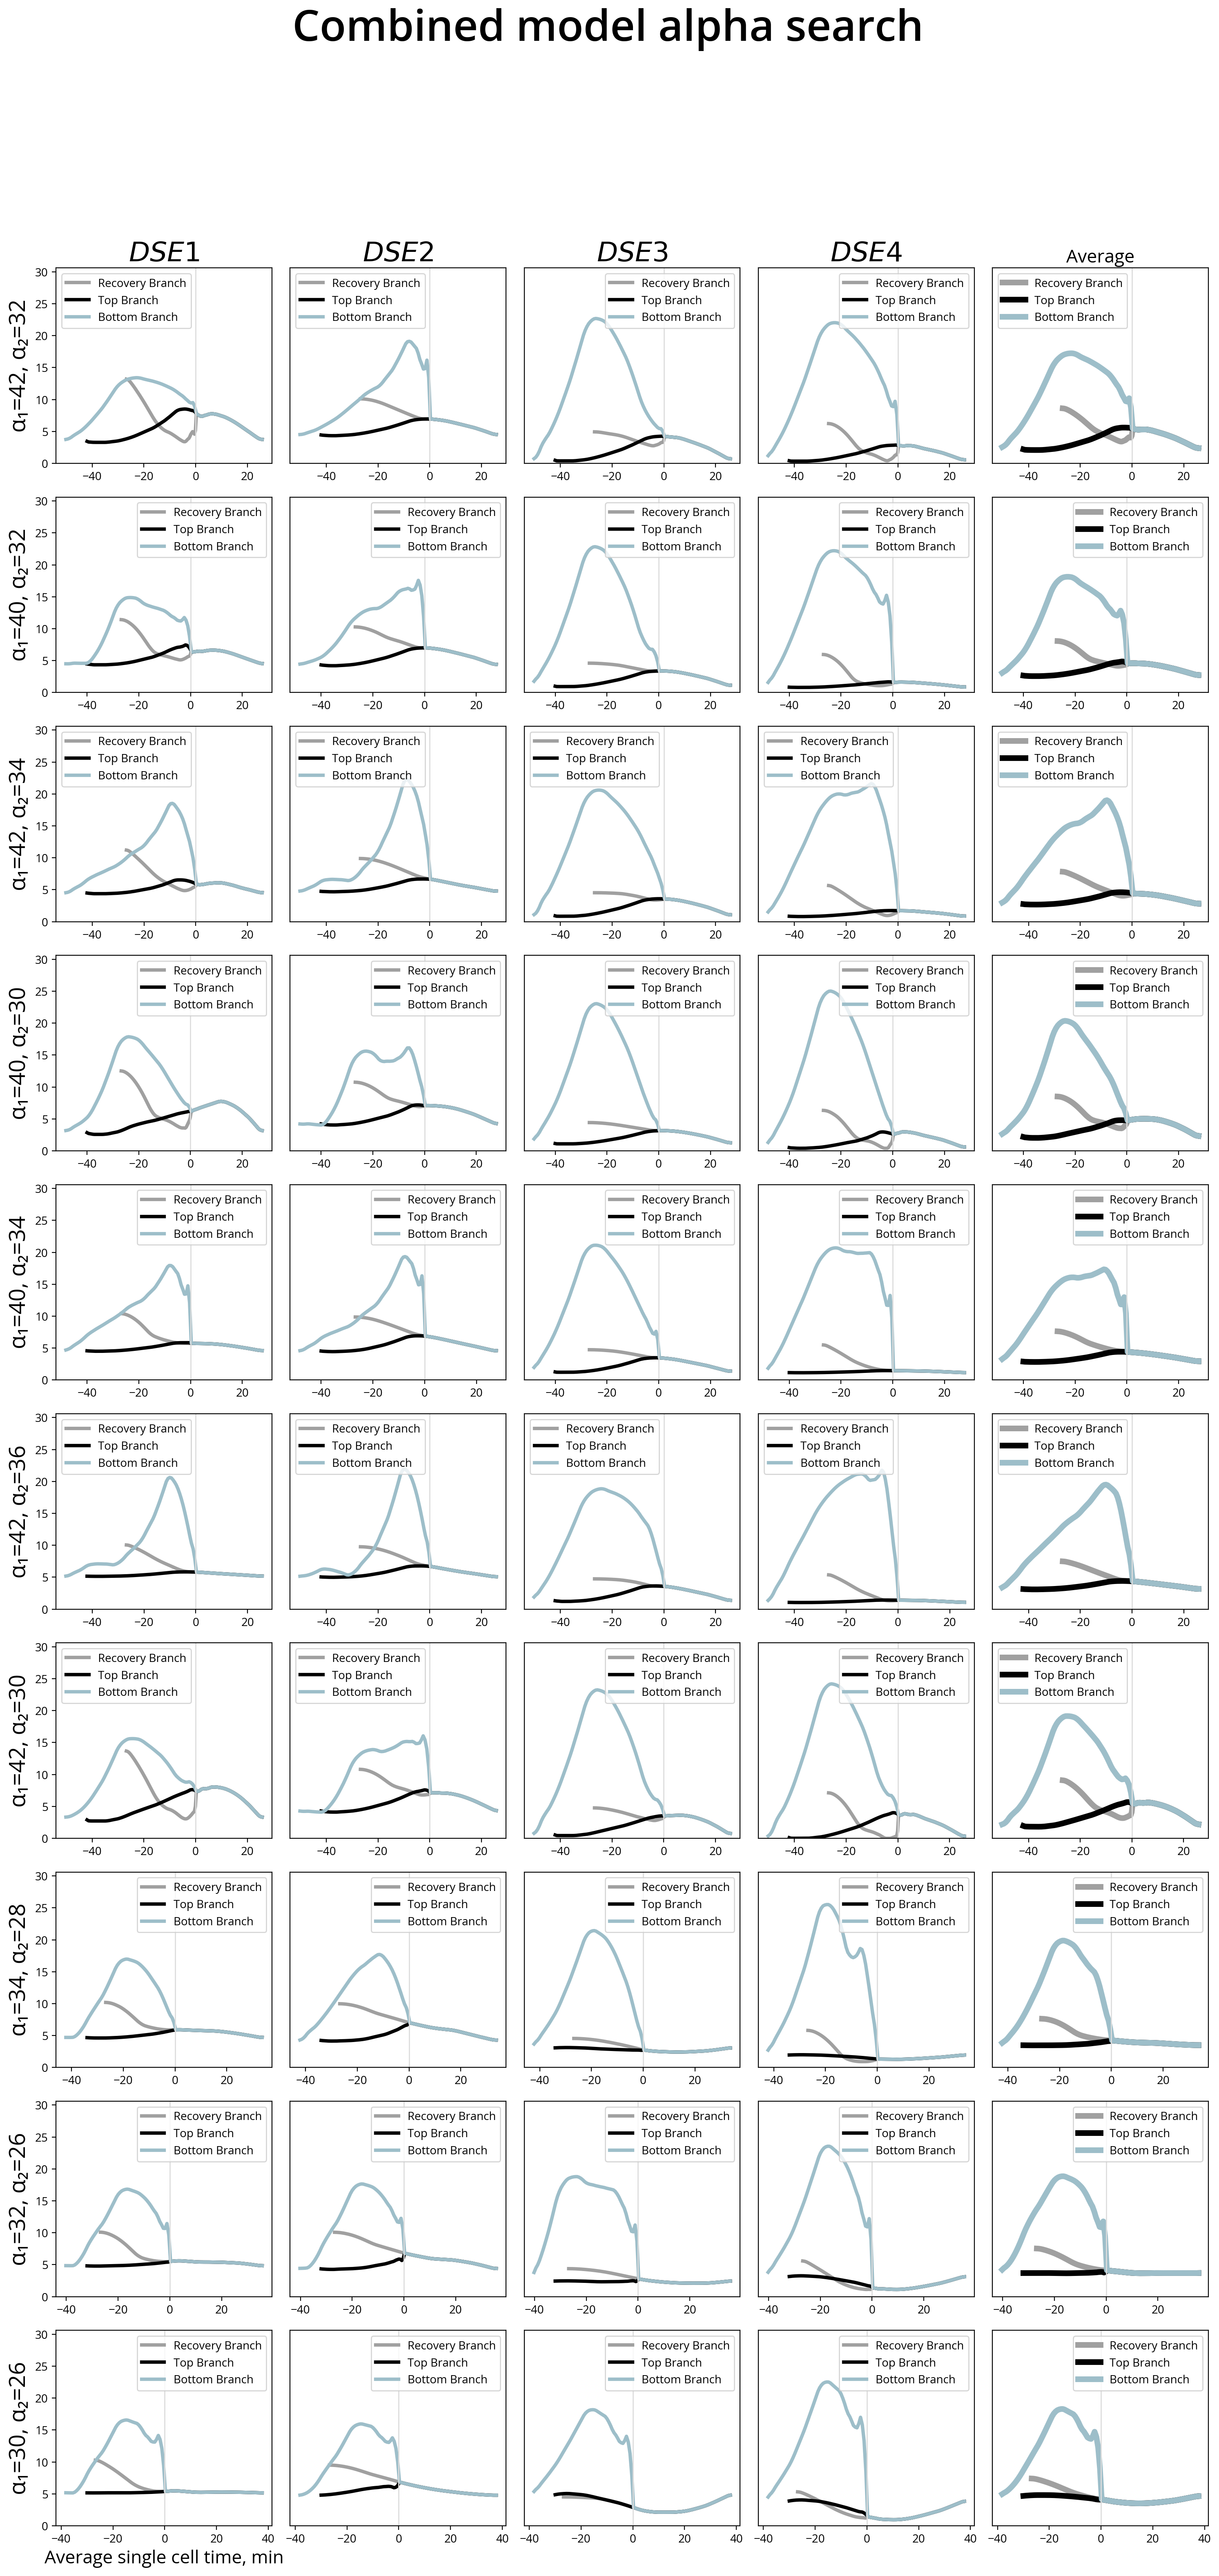

In [19]:
finder2.save_combined_gene_results()
fig = finder2.save_combined_gene_figures()


In [ ]:
finder2.run_combined_origin_deconvolution(top_n_pairs=10)

Top 10 optimal alpha pairs within feasible ranges:
               correlation
alpha1 alpha2             
42     32         0.922780
40     32         0.918591
42     34         0.909559
40     30         0.875372
       34         0.873510
42     36         0.855471
       30         0.852440
34     28         0.831227
32     26         0.826913
30     26         0.819051
Running combined origin deconvolution for 10 alpha pairs...
Alphas: (42, 32)
Deconvolving origin: oridb_10
Imputing timepoint 50 as average of 40 and 60
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr

 - 00:00:27.064
Deconvolving origin: oridb_295
Imputing timepoint 50 as average of 40 a

In [ ]:
finder2.save_combined_origin_results()

In [ ]:
fig = finder2.save_combined_origin_figures()